# ListOps Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the ListOps dataset.


In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [3]:
from src.eval.compare import load_all_experiments

base_dir = "./runs"
models = ['s4', 'lmu', 'mamba']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "listops"

print("="*60)
print("LOADING ListOps EXPERIMENT RESULTS")
print("="*60)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

LOADING ListOps EXPERIMENT RESULTS

Loading S4 @ 10%: listops_s4_task_frac_10
Loading S4 @ 25%: listops_s4_task_frac_25
Loading S4 @ 50%: listops_s4_task_frac_50
Loading S4 @ 100%: listops_s4_task
Loading LMU @ 10%: listops_lmu_task_frac_10
Loading LMU @ 25%: listops_lmu_task_frac_25
Loading LMU @ 50%: listops_lmu_task_frac_50
Loading LMU @ 100%: listops_lmu_task
Loading MAMBA @ 10%: listops_mamba_task_frac_10
Loading MAMBA @ 25%: listops_mamba_task_frac_25
Loading MAMBA @ 50%: listops_mamba_task_frac_50
Loading MAMBA @ 100%: listops_mamba_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments
MAMBA: Loaded 4/4 experiments


## Results Summary Table


In [4]:
from src.eval.compare import create_test_comparison_table

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['accuracy', 'loss']
)

pd.options.display.float_format = '{:.4f}'.format


print("\n" + "="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['accuracy'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (Accuracy: {best_row['accuracy']*100:.2f}%)")

print()
test_comparison_df



BEST MODEL PER DATA FRACTION

10% data: LMU (Accuracy: 37.00%)

25% data: S4 (Accuracy: 37.55%)

50% data: LMU (Accuracy: 38.20%)

100% data: MAMBA (Accuracy: 42.85%)



,model,data_pct,accuracy,loss,num_samples
0,LMU,10,0.3700,1.6975,2000
1,LMU,25,0.3750,1.6588,2000
2,LMU,50,0.3820,1.6038,2000
3,LMU,100,0.3880,1.5839,2000
4,MAMBA,10,0.1780,2.2598,2000
5,MAMBA,25,0.2325,2.2324,2000
6,MAMBA,50,0.3720,1.7125,2000
7,MAMBA,100,0.4285,1.4501,2000
8,S4,10,0.3685,1.7144,2000
9,S4,25,0.3755,1.6402,2000


## Visualization: Test Accuracy Comparison

Compare test accuracy of S4 and LMU across different data fractions.


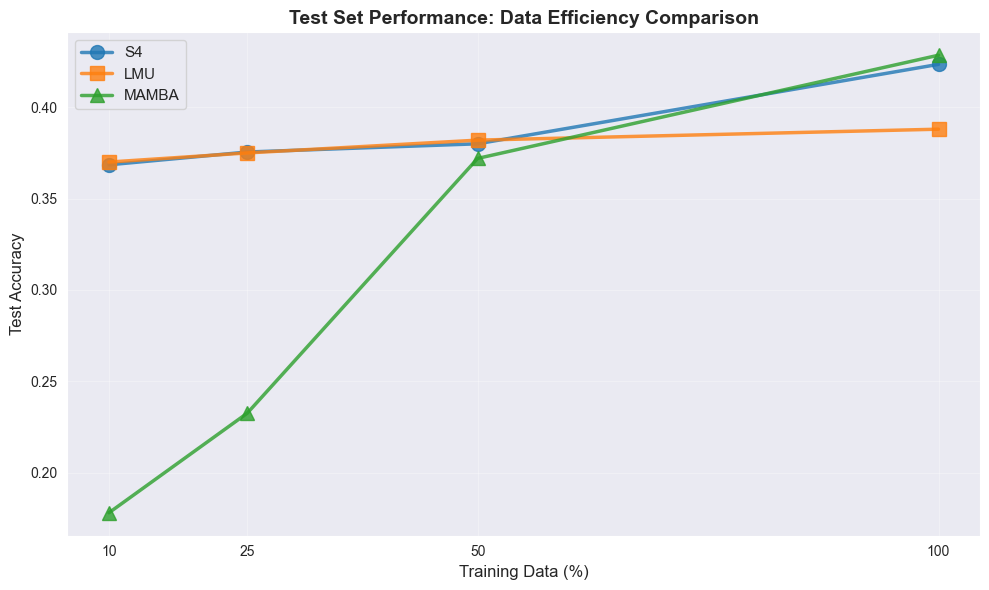

In [5]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='accuracy',
    ylabel='Test Accuracy'
)

## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


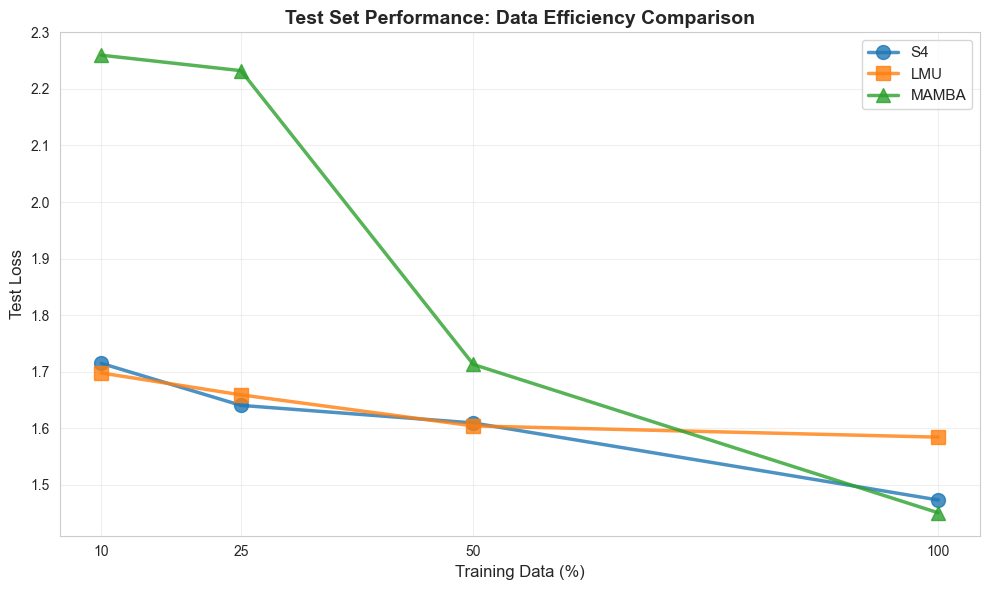

In [12]:
plot_test_data_efficiency(
    all_results,
    metric_key='loss',
    ylabel='Test Loss'
)

## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


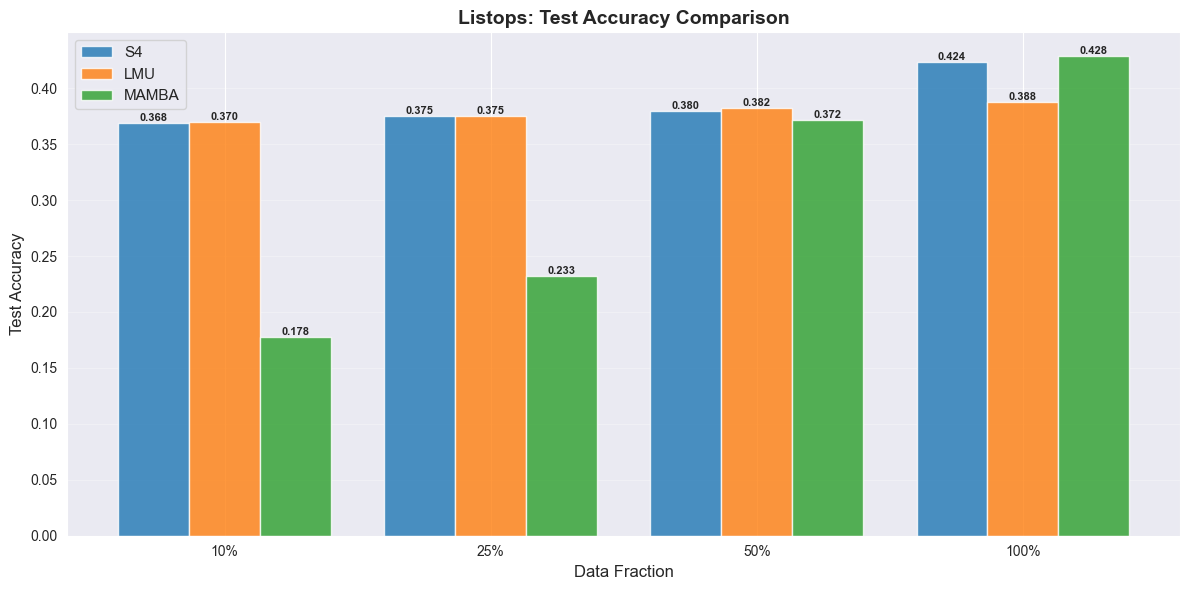

In [6]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='accuracy',
    title='Listops: Test Accuracy Comparison',
    ylabel='Test Accuracy',
)

### Heatmap Visualization

Visual comparison of test accuracy across models and data fractions.


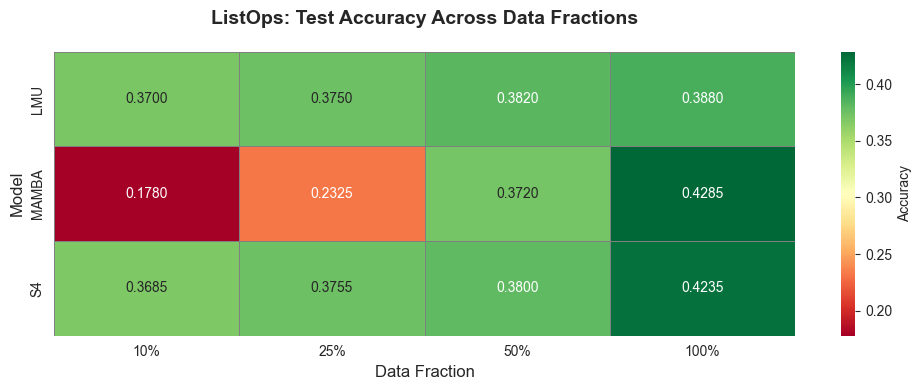

In [14]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='accuracy',
    title='ListOps: Test Accuracy Across Data Fractions',
    annot_format='.4f'
)